<a href="https://colab.research.google.com/github/dayanamichellgomezmartinez-ux/Notebooks_Agro_2026_1/blob/main/Ejercicios__metodos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**EJERCICIOS METODOS NUMERICOS**

**DAYANA GOMEZ MARTINEZ**

**EJERCICIO 1**

# Interacciones     x0         x1         xr         f(x0)          f(xr)        f(x0)*f(xr)           ER%        
       0           1.50000    2.00000    1.75000      0.1807235     -0.5629042      -0.10173000         -         
       1           1.50000    1.75000    1.62500      0.1807235     -0.1547708      -0.02797072          7.6923077
       2           1.50000    1.62500    1.56250      0.1807235      0.0224479       0.00405686          4.0000000
       3           1.56250    1.62500    1.59375      0.0224479     -0.0638350      -0.00143296          1.9607843
       4           1.56250    1.59375    1.57812      0.0224479     -0.0201063      -0.00045134          0.9900990
       5           1.56250    1.57812    1.57031      0.0224479      0.0013183       0.00002959          0.4975124
       6           1.57031    1.57812    1.57422      0.0013183     -0.0093572      -0.00001234          0.2481390
       7           1.57031    1.57422    1.57227      0.0013183     -0.0040103  

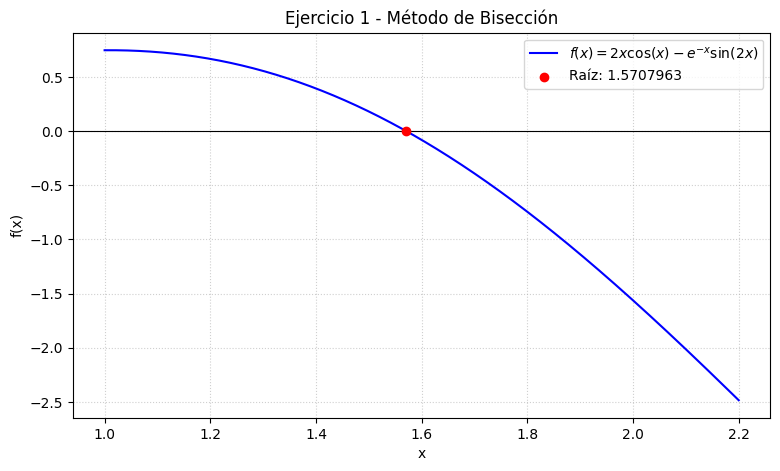

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return 2 * x * np.cos(x) - np.exp(-x) * np.sin(2 * x)

def main():
    x0 = 1.5
    x1 = 2.0
    tol_error = 1e-7

    xr_anterior = None
    i = 0

    print('{:^15s} {:^10s} {:^10s} {:^10s} {:^14s} {:^14s} {:^16s} {:^18s}'.format(
        '# Interacciones', 'x0', 'x1', 'xr', 'f(x0)', 'f(xr)', 'f(x0)*f(xr)', 'ER%'))

    while True:
        xr = (x0 + x1) / 2
        fx0 = f(x0)
        fxr = f(xr)
        prod = fx0 * fxr

        if xr_anterior is None:
            er_str = "{:^18s}".format("-")
            er_val = 100.0
        else:
            er_val = abs((xr - xr_anterior) / xr) * 100 if xr != 0 else 0
            if er_val < 1e-3:
                er_str = "{:18.5E}".format(er_val)
            else:
                er_str = "{:18.7f}".format(er_val)

        print('{:^15d} {:10.5f} {:10.5f} {:10.5f} {:14.7f} {:14.7f} {:16.8f} {}'.format(
            i, x0, x1, xr, fx0, fxr, prod, er_str))

        if xr_anterior is not None and er_val <= tol_error:
            raiz = xr
            break

        if prod < 0:
            x1 = xr
        else:
            x0 = xr

        xr_anterior = xr
        i += 1

    print('\nLa raíz encontrada es: {:.10f}'.format(raiz))

    # Gráfica
    x_range = np.linspace(1.0, 2.2, 500)
    plt.figure(figsize=(9, 5))
    plt.plot(x_range, f(x_range), label=r'$f(x) = 2x\cos(x) - e^{-x}\sin(2x)$', color='blue')
    plt.axhline(0, color='black', linewidth=0.8)
    plt.scatter([raiz], [f(raiz)], color='red', zorder=5, label=f'Raíz: {raiz:.7f}')
    plt.title('Ejercicio 1 - Método de Bisección')
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()

if __name__ == '__main__':
    main()

**Ejercicio 2: Ecuación de Antoine**

# Interacciones     T0         T1         Tr         f(T0)          f(Tr)        f(T0)*f(Tr)           ER%        
       0           5.00000   50.00000   27.50000     -0.1872524      0.4386632      -0.08214074         -         
       1           5.00000   27.50000   16.25000     -0.1872524      0.1398068      -0.02617915         69.2307692
       2           5.00000   16.25000   10.62500     -0.1872524     -0.0199537       0.00373638         52.9411765
       3          10.62500   16.25000   13.43750     -0.0199537      0.0608366      -0.00121392         20.9302326
       4          10.62500   13.43750   12.03125     -0.0199537      0.0206729      -0.00041250         11.6883117
       5          10.62500   12.03125   11.32812     -0.0199537      0.0004179      -0.00000834          6.2068966
       6          10.62500   11.32812   10.97656     -0.0199537     -0.0097532       0.00019461          3.2028470
       7          10.97656   11.32812   11.15234     -0.0097532     -0.0046640  

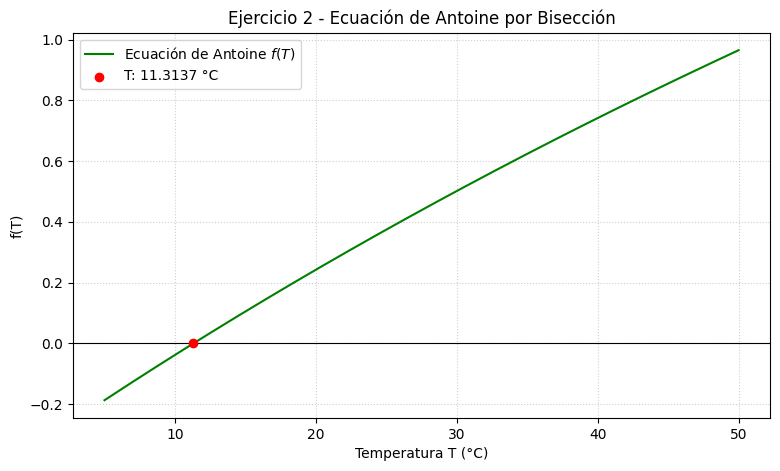

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Constantes según tu cuaderno
P = 10.0
A = 8.07131
B = 1730.63
C = 233.426

def f(T):
    return A - (B / (T + C)) - np.log10(P)

def main():
    # Intervalo dado en la foto [5, 50]
    T0 = 5.0
    T1 = 50.0
    tol_error = 1e-6

    Tr_anterior = None
    i = 0

    print('{:^15s} {:^10s} {:^10s} {:^10s} {:^14s} {:^14s} {:^16s} {:^18s}'.format(
        '# Interacciones', 'T0', 'T1', 'Tr', 'f(T0)', 'f(Tr)', 'f(T0)*f(Tr)', 'ER%'))

    while True:
        Tr = (T0 + T1) / 2
        fT0 = f(T0)
        fTr = f(Tr)
        prod = fT0 * fTr

        if Tr_anterior is None:
            er_str = "{:^18s}".format("-")
            er_val = 100.0
        else:
            er_val = abs((Tr - Tr_anterior) / Tr) * 100 if Tr != 0 else 0
            if er_val < 1e-3:
                er_str = "{:18.5E}".format(er_val)
            else:
                er_str = "{:18.7f}".format(er_val)

        print('{:^15d} {:10.5f} {:10.5f} {:10.5f} {:14.7f} {:14.7f} {:16.8f} {}'.format(
            i, T0, T1, Tr, fT0, fTr, prod, er_str))

        if Tr_anterior is not None and er_val <= tol_error:
            raiz = Tr
            break

        if prod < 0:
            T1 = Tr
        else:
            T0 = Tr

        Tr_anterior = Tr
        i += 1

    print('\nLa temperatura T encontrada es: {:.10f} °C'.format(raiz))

    # Gráfica
    T_range = np.linspace(5.0, 50.0, 500)
    plt.figure(figsize=(9, 5))
    plt.plot(T_range, f(T_range), label=r'Ecuación de Antoine $f(T)$', color='green')
    plt.axhline(0, color='black', linewidth=0.8)
    plt.scatter([raiz], [f(raiz)], color='red', zorder=5, label=f'T: {raiz:.4f} °C')
    plt.title('Ejercicio 2 - Ecuación de Antoine por Bisección')
    plt.xlabel('Temperatura T (°C)')
    plt.ylabel('f(T)')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()

if __name__ == '__main__':
    main()

**EJERCICIO 3**

# Interacciones     f0         f1         fr         g(f0)          g(fr)        g(f0)*g(fr)           ER%        
       0          0.008000   0.080000   0.044000     16.5264242     10.8102447     178.65469061         -         
       1          0.044000   0.080000   0.062000     10.8102447     10.1942358     110.20218396         29.0322581
       2          0.062000   0.080000   0.071000     10.1942358      9.9838974     101.77820429         12.6760563
       3          0.071000   0.080000   0.075500      9.9838974      9.8941633      98.78231130          5.9602649
       4          0.075500   0.080000   0.077750      9.8941633      9.8524747      97.48199402          2.8938907
       5          0.077750   0.080000   0.078875      9.8524747      9.8323564      96.87304313          1.4263074
       6          0.078875   0.080000   0.079437      9.8323564      9.8224710      96.57803518          0.7081039
       7          0.079437   0.080000   0.079719      9.8224710      9.8175707  

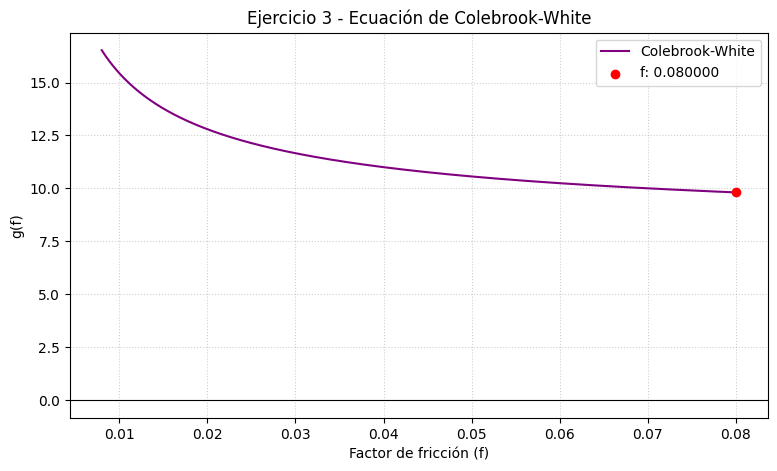

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Datos de tu cuaderno
e = 1.5e-6
D = 5.0e-3
Re = 13743.017

def g(f_val):
    term = ((e / D) / 3.7) + (2.51 / (Re * np.sqrt(f_val)))
    return (1.0 / np.sqrt(f_val)) - 2.0 * np.log10(term)

def main():
    # Intervalo representativo para el factor de fricción de Darcy
    f0 = 0.008
    f1 = 0.08
    tol_error = 1e-6

    fr_anterior = None
    i = 0

    print('{:^15s} {:^10s} {:^10s} {:^10s} {:^14s} {:^14s} {:^16s} {:^18s}'.format(
        '# Interacciones', 'f0', 'f1', 'fr', 'g(f0)', 'g(fr)', 'g(f0)*g(fr)', 'ER%'))

    while True:
        fr = (f0 + f1) / 2
        gf0 = g(f0)
        gfr = g(fr)
        prod = gf0 * gfr

        if fr_anterior is None:
            er_str = "{:^18s}".format("-")
            er_val = 100.0
        else:
            er_val = abs((fr - fr_anterior) / fr) * 100 if fr != 0 else 0
            if er_val < 1e-3:
                er_str = "{:18.5E}".format(er_val)
            else:
                er_str = "{:18.7f}".format(er_val)

        print('{:^15d} {:10.6f} {:10.6f} {:10.6f} {:14.7f} {:14.7f} {:16.8f} {}'.format(
            i, f0, f1, fr, gf0, gfr, prod, er_str))

        if fr_anterior is not None and er_val <= tol_error:
            raiz = fr
            break

        if prod < 0:
            f1 = fr
        else:
            f0 = fr

        fr_anterior = fr
        i += 1

    print('\nEl factor de fricción f encontrado es: {:.10f}'.format(raiz))

    # Gráfica
    f_range = np.linspace(0.008, 0.08, 500)
    plt.figure(figsize=(9, 5))
    plt.plot(f_range, g(f_range), label='Colebrook-White', color='purple')
    plt.axhline(0, color='black', linewidth=0.8)
    plt.scatter([raiz], [g(raiz)], color='red', zorder=5, label=f'f: {raiz:.6f}')
    plt.title('Ejercicio 3 - Ecuación de Colebrook-White')
    plt.xlabel('Factor de fricción (f)')
    plt.ylabel('g(f)')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()

if __name__ == '__main__':
    main()